In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import kagglehub

### Download Dataset

In [2]:
# Download latest version
path = kagglehub.dataset_download("samfaraday/daily-minimum-temperatures-in-me")

In [3]:
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/root/.cache/kagglehub/datasets/samfaraday/daily-minimum-temperatures-in-me/versions/1/daily-minimum-temperatures-in-me.csv


         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
Index(['Date', 'Temp'], dtype='object')


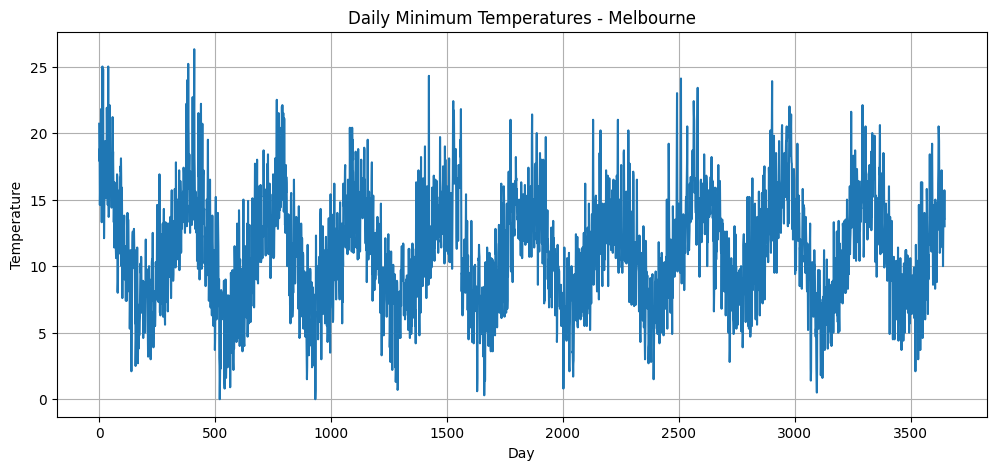

In [4]:
csv_path = os.path.join(path, "daily-minimum-temperatures-in-me.csv")
df = pd.read_csv(csv_path, on_bad_lines="skip")
df.columns = ["Date", "Temp"]
print(df.head())
print(df.columns)

df["Temp"] = pd.to_numeric(df["Temp"], errors="coerce")
# Drop bad rows
df = df.dropna(subset=["Temp"]).reset_index(drop=True)

temperatures = df['Temp'].values.astype(np.float32)

plt.figure(figsize=(12, 5))
plt.plot(temperatures)
plt.title("Daily Minimum Temperatures - Melbourne")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.grid(True)
plt.show()

In [5]:
#Define a look_back window size
look_back = 20

#Prepare empty lists to store sequences
X = []
y = []

#Create input-output pairs
for i in range(len(temperatures) - look_back):
    # 3. Input sequence (X) and target value (y)
    feature_sequence = temperatures[i:(i + look_back)]
    target_value = temperatures[i + look_back]
    X.append(feature_sequence)
    y.append(target_value)

#Convert lists to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target values): {y.shape}")
print("First 5 input sequences:\n", X[:5])
print("First 5 target values:\n", y[:5])

Shape of X (input sequences): (3627, 20)
Shape of y (target values): (3627,)
First 5 input sequences:
 [[20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5
  25.  20.7 20.6 24.8 17.7 15.5]
 [17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5 25.
  20.7 20.6 24.8 17.7 15.5 18.2]
 [18.8 14.6 15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5 25.  20.7
  20.6 24.8 17.7 15.5 18.2 12.1]
 [14.6 15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5 25.  20.7 20.6
  24.8 17.7 15.5 18.2 12.1 14.4]
 [15.8 15.8 15.8 17.4 21.8 20.  16.2 13.3 16.7 21.5 25.  20.7 20.6 24.8
  17.7 15.5 18.2 12.1 14.4 16. ]]
First 5 target values:
 [18.2 12.1 14.4 16.  16.5]


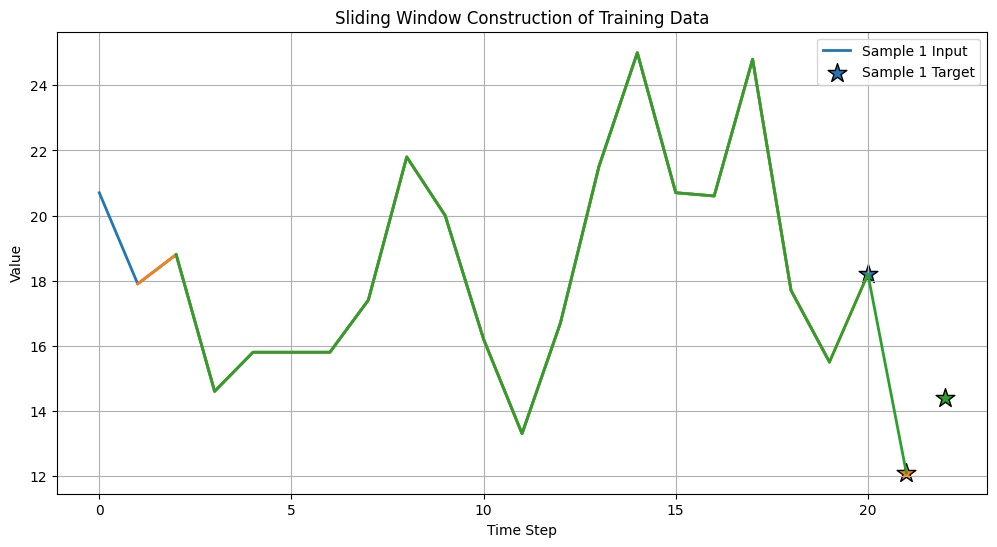

In [6]:
#Number of examples to visualize
num_examples = 3

plt.figure(figsize=(12, 6))

for i in range(num_examples):
    input_sequence = X[i]
    target_value = y[i]

    #X-axis positions
    input_timesteps = np.arange(i, i + look_back)
    target_timestep = i + look_back


    base_color = f"C{i}"

    #Plot input sequence
    plt.plot(
        input_timesteps,
        input_sequence,
        color=base_color,
        linestyle='-',
        linewidth=2,
        label=f"Sample {i+1} Input" if i == 0 else None
    )

    #Plot target point
    plt.scatter(
        target_timestep,
        target_value,
        color=base_color,
        marker='*',
        s=200,
        edgecolor='black',
        label=f"Sample {i+1} Target" if i == 0 else None
    )

plt.title("Sliding Window Construction of Training Data")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

Build the RNN


In [7]:
#Convert NumPy arrays to PyTorch tensors and reshape X
#Ensure X has shape (batch_size, sequence_length, input_size)
#For univariate time series, input_size is 1
X_tensor = torch.from_numpy(X).float().unsqueeze(-1) #Add a feature dimension
y_tensor = torch.from_numpy(y).float()

print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

#Split data into training and testing sets
train_size = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:train_size], X_tensor[train_size:]
y_train, y_test = y_tensor[:train_size], y_tensor[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


class RNNModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size

        #Define the rNN layer and a linear layer
        #batch_first=True means input/output tensors are (batch_size, seq_len, features)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    # 5. Define the forward pass
    def forward(self, x):
        #Initialize hidden state with zeros
        #(num_layers * num_directions, batch_size, hidden_size)
        h0 = torch.zeros(1, x.size(0), self.hidden_size).to(x.device)

        #Forward propagate RNN
        out, _ = self.rnn(x, h0)

        #Pass the output of the last time step to the linear layer
        #out[:, -1, :] takes the hidden state of the last time step
        out = self.fc(out[:, -1, :])

        #Another option
        #out, hnn = self.rnn(x)
        #logits = self.fc(hn[-1])
        return out

print("RNNModel class defined successfully.")

Shape of X_tensor: torch.Size([3627, 20, 1])
Shape of y_tensor: torch.Size([3627])
Shape of X_train: torch.Size([2901, 20, 1])
Shape of y_train: torch.Size([2901])
Shape of X_test: torch.Size([726, 20, 1])
Shape of y_test: torch.Size([726])
RNNModel class defined successfully.


Train the RNN Model

In [48]:
#Instantiate the RNNModel
input_size = 1
hidden_size = 500
output_size = 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNModel(input_size, hidden_size, output_size).to(device)

#Define loss function and optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

#Define number of training epochs
num_epochs = 1000

#Move data to the same device as the model
X_train = X_train.to(device)
y_train = y_train.to(device)

#Create a training loop
print("Starting RNN model training...")
for epoch in range(num_epochs):
    #Forward pass
    model.train() #Set model to train mode
    outputs = model(X_train)

    #Reshape outputs to match y_train shape if necessary
    #outputs.squeeze() handles cases where output is (batch_size, 1) and y_train is (batch_size)
    loss = criterion(outputs.squeeze(), y_train)

    #Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #Print loss every few epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("RNN model training complete.")

Starting RNN model training...
Epoch [100/1000], Loss: 14.7275
Epoch [200/1000], Loss: 7.5834
Epoch [300/1000], Loss: 6.5836
Epoch [400/1000], Loss: 6.0268
Epoch [500/1000], Loss: 5.9156
Epoch [600/1000], Loss: 5.9639
Epoch [700/1000], Loss: 5.9690
Epoch [800/1000], Loss: 5.6633
Epoch [900/1000], Loss: 5.6016
Epoch [1000/1000], Loss: 5.4795
RNN model training complete.


Prediction evaluation



Test Loss: 4.9731


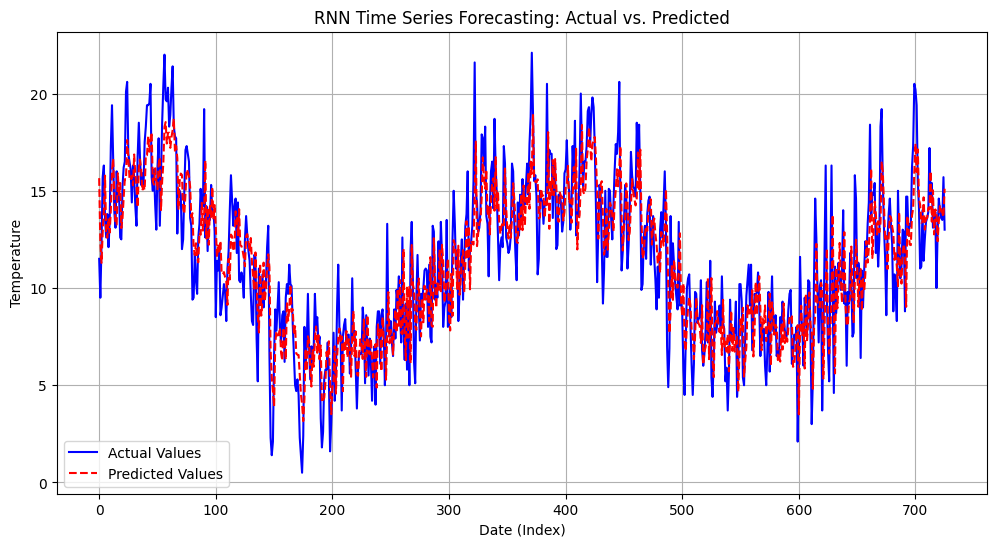

In [49]:
#Move test data to the same device as the model
X_test = X_test.to(device)
y_test = y_test.to(device)

#Evaluate the model on the test set
model.eval() #Set the model to evaluation mode
with torch.no_grad(): #Disable gradient calculation for evaluation
    test_predictions = model(X_test)
    test_loss = criterion(test_predictions.squeeze(), y_test)

print(f'Test Loss: {test_loss.item():.4f}')

#Visualize predictions against actual values
#Move data back to CPU for plotting
predictions_np = test_predictions.cpu().numpy().squeeze()
actual_np = y_test.cpu().numpy()

plt.figure(figsize=(12, 6))
plt.plot(actual_np, label='Actual Values', color='blue')
plt.plot(predictions_np, label='Predicted Values', color='red', linestyle='--')
plt.title('RNN Time Series Forecasting: Actual vs. Predicted')
plt.xlabel('Date (Index)')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True)
plt.show()
